# Financial News in Indonesian Language Sentiment Classification Using Traditional NLP Approaches and Modern Transformer-Based Language Models

## Ernest Ferdian


### Executive Summary

Financial markets are highly influenced by news sentiment, and traders, analysts, and automated trading systems increasingly rely on Natural Language Processing (NLP) techniques to understand market reactions and investor sentiment. In Indonesia, financial news sentiment analysis remains relatively underdeveloped, particularly for Indonesian-language financial text. This project develops and evaluates an Indonesian financial news sentiment classification system using both traditional NLP approaches and modern Transformer-based language models. This project demonstrates and compares the performance between traditional NLP models and modern transformer-based LLM on non-english language specific-industry language, specifically Indonesian-language financial text.

The project uses the CNBC Indonesia Stock News Sentiment Dataset, which contains 9,819 Indonesian financial news headlines manually labeled into three sentiment categories: positive, neutral, and negative. The dataset includes a broad range of market-related news and provides a realistic benchmark for financial sentiment classification in Indonesian language.

To study the effectiveness of different NLP approaches, three models were implemented and compared. First, a TF-IDF + Logistic Regression model was used as a classical machine learning baseline. Second, an Embedding + Bidirectional LSTM (BiLSTM) neural network model was implemented to capture sequential text patterns. Finally, a Transformer-based Large Language Model approach was developed by fine-tuning IndoBERT using the Hugging Face Transformers framework in Python. Afterwards, the project compares the performance across the three models.

The results show that the fine-tuned IndoBERT model significantly outperformed the traditional and BiLSTM models across all evaluation metrics. IndoBERT achieved approximately 87.6% accuracy and 0.876 macro F1 score, compared to approximately 80% performance from the TF-IDF and BiLSTM approaches. The confusion matrix analysis further showed that IndoBERT reduced classification confusion between positive, neutral, and negative sentiment classes, especially for financially nuanced headlines.

The findings suggest that Transformer-based language models are more effective for Indonesian financial sentiment analysis because they better capture contextual and semantic meaning compared to bag-of-words or sequential neural approaches.

Based on qualitative analysis of the misclassification, there are still works needed on emotionally charged words, such as corruption and loan. IndoBERT still have difficulties understanding the context and sentiment in the presence of emotionally charged words.



### Dataset

For the dataset, I used the CNBC Indonesia Stock News Sentiment Dataset from [Kaggle](https://www.kaggle.com/datasets/triagungj/cnbc-indonesia-stock-news-sentiment-dataset). This dataset contains 9,819 Indonesian stock market news headlines published on CNBC Indonesia. Each headline has been manually labeled with one of three sentiment classes: positive, neutral and negative. The dataset can be obtained from [this Kaggle link.](https://www.kaggle.com/datasets/triagungj/cnbc-indonesia-stock-news-sentiment-dataset)

### Required Libraries Installation

This project is run using Google Colab

In [2]:
!pip install -q transformers datasets evaluate accelerate scikit-learn tensorflow matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.4 MB/s eta 0:00:00


In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

SEED = 123

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

## Data Preparation & Exploration

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Dataset-CNBCI-Sentimented.csv to Dataset-CNBCI-Sentimented.csv


In [4]:
DATA_PATH = "Dataset-CNBCI-Sentimented.csv"

data_raw = pd.read_csv(DATA_PATH)

print("Columns in dataset:")
print(data_raw.columns.tolist())

print("\nFirst 3 rows:")
display(data_raw.head(3))

Columns in dataset:
['judul', 'tanggal', 'sentimen']

First 3 rows:


,judul,tanggal,sentimen
0,"Direktur Garuda Salman El Farisiy Meninggal, I...",2024/01/01,negatif
1,"Catatan Sejarah 2023, Indonesia Luncurkan Burs...",2024/01/01,netral
2,"Ramalan Bitcoin Paling Gila 2024, Naik 1.000% ...",2024/01/01,netral


In [5]:
TEXT_COL = "judul"
LABEL_COL = "sentimen"

data_raw.columns = data_raw.columns.str.lower()

text_col = TEXT_COL.lower()
label_col = LABEL_COL.lower()

if text_col not in data_raw.columns:
    raise ValueError(f"Text column '{text_col}' not found.")

if label_col not in data_raw.columns:
    raise ValueError(f"Label column '{label_col}' not found.")

data = data_raw[[text_col, label_col]].copy()
data.columns = ["text_raw", "label_raw"]

display(data.head(3))

,text_raw,label_raw
0,"Direktur Garuda Salman El Farisiy Meninggal, I...",negatif
1,"Catatan Sejarah 2023, Indonesia Luncurkan Burs...",netral
2,"Ramalan Bitcoin Paling Gila 2024, Naik 1.000% ...",netral


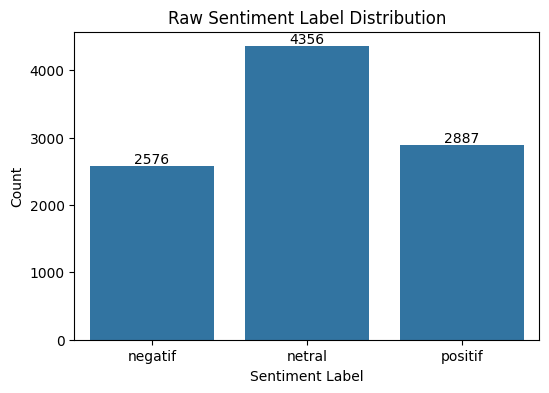

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x="label_raw")
plt.title("Raw Sentiment Label Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

In [7]:
def normalize_label(x):
    if pd.isna(x):
        return None

    if isinstance(x, (int, float, np.integer, np.floating)):
        if x < 0:
            return "negative"
        elif x > 0:
            return "positive"
        else:
            return "neutral"

    lab = str(x).strip().lower()

    if lab in ["pos", "positive", "positif"]:
        return "positive"
    elif lab in ["neg", "negative", "negatif"]:
        return "negative"
    elif lab in ["neu", "neutral", "netral"]:
        return "neutral"
    else:
        return None

data["sentiment"] = data["label_raw"].apply(normalize_label)

label_order = ["negative", "neutral", "positive"]
data = data.dropna(subset=["sentiment"])
data["sentiment"] = pd.Categorical(data["sentiment"], categories=label_order, ordered=True)

print("Sentiment label distribution:")
print(data["sentiment"].value_counts().reindex(label_order))

Sentiment label distribution:
sentiment
negative    2576
neutral     4356
positive    2887
Name: count, dtype: int64


In [8]:
def clean_text(x):
    x = str(x).lower()
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()

data["text"] = data["text_raw"].apply(clean_text)
data = data[data["text"] != ""].copy()

print("Sample cleaned Indonesian texts:")
display(data[["text_raw", "text", "sentiment"]].head())

print("\nTotal observations after cleaning:", len(data))

Sample cleaned Indonesian texts:


,text_raw,text,sentiment
0,"Direktur Garuda Salman El Farisiy Meninggal, I...",direktur garuda salman el farisiy meninggal in...,negative
1,"Catatan Sejarah 2023, Indonesia Luncurkan Burs...",catatan sejarah 2023 indonesia luncurkan bursa...,neutral
2,"Ramalan Bitcoin Paling Gila 2024, Naik 1.000% ...",ramalan bitcoin paling gila 2024 naik 1 000 ja...,neutral
3,Wah! Segini Harta Mantan Istri Prabowo Titiek ...,wah segini harta mantan istri prabowo titiek s...,neutral
4,"Pensiun di Oktober 2024, Jokowi Kantongi Uang ...",pensiun di oktober 2024 jokowi kantongi uang p...,neutral



Total observations after cleaning: 9819


In [9]:
label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

data["label"] = data["sentiment"].map(label2id).astype(int)

display(data.head())

,text_raw,label_raw,sentiment,text,label
0,"Direktur Garuda Salman El Farisiy Meninggal, I...",negatif,negative,direktur garuda salman el farisiy meninggal in...,0
1,"Catatan Sejarah 2023, Indonesia Luncurkan Burs...",netral,neutral,catatan sejarah 2023 indonesia luncurkan bursa...,1
2,"Ramalan Bitcoin Paling Gila 2024, Naik 1.000% ...",netral,neutral,ramalan bitcoin paling gila 2024 naik 1 000 ja...,1
3,Wah! Segini Harta Mantan Istri Prabowo Titiek ...,netral,neutral,wah segini harta mantan istri prabowo titiek s...,1
4,"Pensiun di Oktober 2024, Jokowi Kantongi Uang ...",netral,neutral,pensiun di oktober 2024 jokowi kantongi uang p...,1


In [10]:
train_df, temp_df = train_test_split(
    data,
    test_size=0.30,
    stratify=data["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

print("\nTrain label distribution:")
print(train_df["sentiment"].value_counts().reindex(label_order))

print("\nValidation label distribution:")
print(val_df["sentiment"].value_counts().reindex(label_order))

print("\nTest label distribution:")
print(test_df["sentiment"].value_counts().reindex(label_order))

Train size: 6873
Validation size: 1473
Test size: 1473

Train label distribution:
sentiment
negative    1803
neutral     3049
positive    2021
Name: count, dtype: int64

Validation label distribution:
sentiment
negative    386
neutral     654
positive    433
Name: count, dtype: int64

Test label distribution:
sentiment
negative    387
neutral     653
positive    433
Name: count, dtype: int64


## Model Training

In [11]:
def compute_sklearn_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Macro Precision": precision_macro,
        "Macro Recall": recall_macro,
        "Macro F1": f1_macro,
        "Weighted Precision": precision_weighted,
        "Weighted Recall": recall_weighted,
        "Weighted F1": f1_weighted
    }


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order
    )
    plt.title(title)
    plt.xlabel("Predicted Sentiment")
    plt.ylabel("True Sentiment")
    plt.show()

## Model A: Classical Model Baseline TF-IDF + Logistic Regression

=== Baseline: TF-IDF + Logistic Regression ===
              precision    recall  f1-score   support

    negative       0.80      0.79      0.79       387
     neutral       0.84      0.82      0.83       653
    positive       0.77      0.81      0.79       433

    accuracy                           0.81      1473
   macro avg       0.80      0.80      0.80      1473
weighted avg       0.81      0.81      0.81      1473



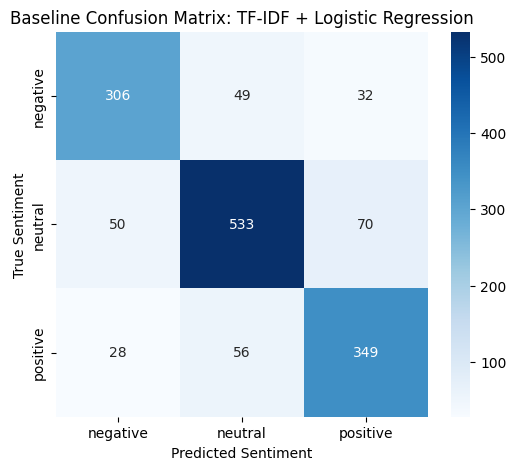

In [13]:
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])
X_test_tfidf = tfidf.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=SEED
)

baseline_model.fit(X_train_tfidf, y_train)

pred_baseline = baseline_model.predict(X_test_tfidf)

print("=== Baseline: TF-IDF + Logistic Regression ===")
print(classification_report(y_test, pred_baseline, target_names=label_order, zero_division=0))

baseline_results = compute_sklearn_metrics(
    y_test,
    pred_baseline,
    "TF-IDF + Logistic Regression"
)

plot_confusion_matrix(
    y_test,
    pred_baseline,
    "Baseline Confusion Matrix: TF-IDF + Logistic Regression"
)

## Model B: Neural model - Embedding + BiLSTM

In [14]:
max_words = 20000
maxlen = 60
num_classes = 3

keras_tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(train_df["text"])

train_sequences = keras_tokenizer.texts_to_sequences(train_df["text"])
val_sequences = keras_tokenizer.texts_to_sequences(val_df["text"])
test_sequences = keras_tokenizer.texts_to_sequences(test_df["text"])

X_train_seq = pad_sequences(train_sequences, maxlen=maxlen, padding="post", truncating="post")
X_val_seq = pad_sequences(val_sequences, maxlen=maxlen, padding="post", truncating="post")
X_test_seq = pad_sequences(test_sequences, maxlen=maxlen, padding="post", truncating="post")

y_train_cat = tf.keras.utils.to_categorical(train_df["label"], num_classes=num_classes)
y_val_cat = tf.keras.utils.to_categorical(val_df["label"], num_classes=num_classes)
y_test_cat = tf.keras.utils.to_categorical(test_df["label"], num_classes=num_classes)

print(X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

(6873, 60) (1473, 60) (1473, 60)


In [17]:
embedding_dim = 128

bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=maxlen),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(128, return_sequences=False)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(num_classes, activation="softmax")
])

bilstm_model.build(input_shape=(None, maxlen))

bilstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 60, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,839,811 (10.83 MB)

 Trainable params: 2,839,811 (10.83 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_bilstm = bilstm_model.fit(
    X_train_seq,
    y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.5495 - loss: 0.9100 - val_accuracy: 0.6802 - val_loss: 0.7468
Epoch 2/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8049 - loss: 0.4969 - val_accuracy: 0.8160 - val_loss: 0.4758
Epoch 3/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9104 - loss: 0.2509 - val_accuracy: 0.8174 - val_loss: 0.5702
Epoch 4/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9482 - loss: 0.1553 - val_accuracy: 0.8187 - val_loss: 0.6137
Epoch 5/25
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9699 - loss: 0.0957 - val_accuracy: 0.8099 - val_loss: 0.7277


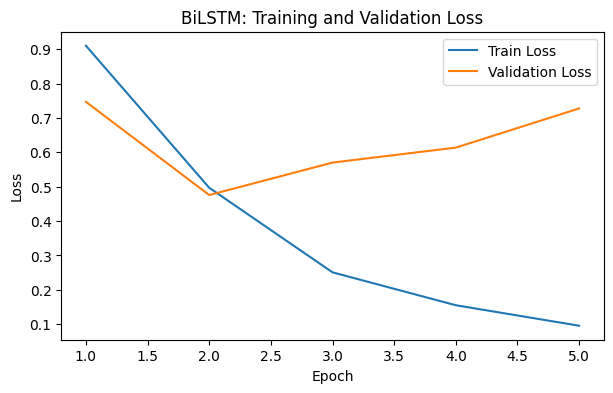

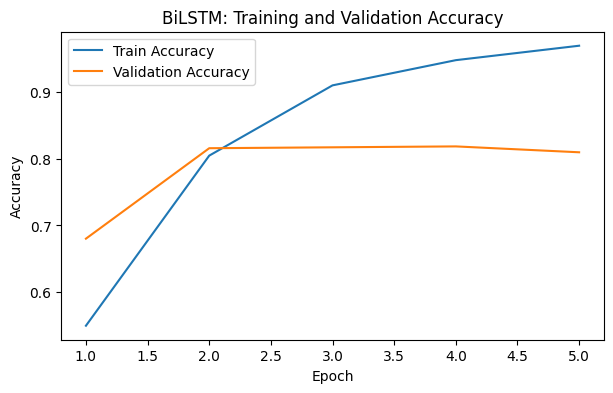

In [19]:
hist = pd.DataFrame(history_bilstm.history)
hist["epoch"] = range(1, len(hist) + 1)

plt.figure(figsize=(7, 4))
plt.plot(hist["epoch"], hist["loss"], label="Train Loss")
plt.plot(hist["epoch"], hist["val_loss"], label="Validation Loss")
plt.title("BiLSTM: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(hist["epoch"], hist["accuracy"], label="Train Accuracy")
plt.plot(hist["epoch"], hist["val_accuracy"], label="Validation Accuracy")
plt.title("BiLSTM: Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
=== Neural Model: Embedding + BiLSTM ===
BiLSTM Test Loss: 0.5031
BiLSTM Test Accuracy: 0.797
              precision    recall  f1-score   support

    negative       0.74      0.79      0.76       387
     neutral       0.85      0.83      0.84       653
    positive       0.78      0.74      0.76       433

    accuracy                           0.80      1473
   macro avg       0.79      0.79      0.79      1473
weighted avg       0.80      0.80      0.80      1473



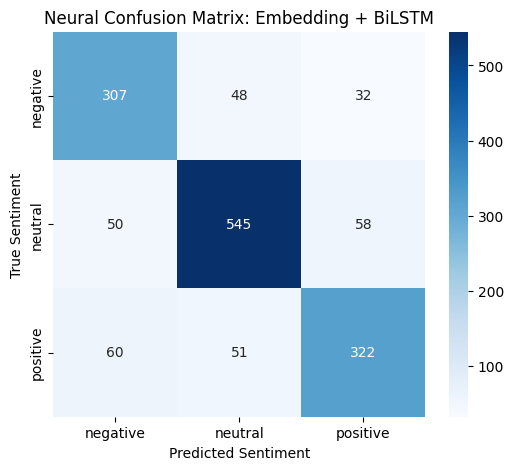

In [20]:
bilstm_loss, bilstm_acc = bilstm_model.evaluate(X_test_seq, y_test_cat, verbose=0)

pred_probs_bilstm = bilstm_model.predict(X_test_seq)
pred_bilstm = np.argmax(pred_probs_bilstm, axis=1)

print("=== Neural Model: Embedding + BiLSTM ===")
print("BiLSTM Test Loss:", round(bilstm_loss, 4))
print("BiLSTM Test Accuracy:", round(bilstm_acc, 4))
print(classification_report(y_test, pred_bilstm, target_names=label_order, zero_division=0))

bilstm_results = compute_sklearn_metrics(
    y_test,
    pred_bilstm,
    "Embedding + BiLSTM"
)

plot_confusion_matrix(
    y_test,
    pred_bilstm,
    "Neural Confusion Matrix: Embedding + BiLSTM"
)

## Model C: LLM-based model - IndoBERT fine-tuning

In [21]:
hf_train = Dataset.from_pandas(train_df[["text", "label"]].reset_index(drop=True))
hf_val = Dataset.from_pandas(val_df[["text", "label"]].reset_index(drop=True))
hf_test = Dataset.from_pandas(test_df[["text", "label"]].reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": hf_train,
    "validation": hf_val,
    "test": hf_test
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6873
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1473
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1473
    })
})

In [22]:
MODEL_NAME = "indobenchmark/indobert-base-p1"

transformer_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return transformer_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

tokenized_dataset = dataset_dict.map(tokenize_function, batched=True)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

tokenized_dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/6873 [00:00<?, ? examples/s]

Map:   0%|          | 0/1473 [00:00<?, ? examples/s]

Map:   0%|          | 0/1473 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6873
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1473
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1473
    })
})

In [23]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

bert_model.to(device)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(50000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [24]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "macro_precision": precision_macro,
        "macro_recall": recall_macro,
        "macro_f1": f1_macro,
        "weighted_precision": precision_weighted,
        "weighted_recall": recall_weighted,
        "weighted_f1": f1_weighted
    }

In [28]:
training_args = TrainingArguments(
    output_dir="./indobert-financial-sentiment",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    report_to="none",
    seed=SEED
)

In [30]:
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics
)

In [31]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
1,0.369132,0.361335,0.851324,0.852328,0.847988,0.848585,0.852975,0.851324,0.850844
2,0.198479,0.373522,0.884589,0.883699,0.885672,0.884460,0.885142,0.884589,0.884680
3,0.064496,0.474701,0.890020,0.888764,0.891497,0.889972,0.890397,0.890020,0.890075


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1290, training_loss=0.2549763892048089, metrics={'train_runtime': 74.9624, 'train_samples_per_second': 275.058, 'train_steps_per_second': 17.209, 'total_flos': 678141945016704.0, 'train_loss': 0.2549763892048089, 'epoch': 3.0})

In [32]:
bert_test_results = trainer.evaluate(tokenized_dataset["test"])

print("=== IndoBERT Test Results ===")
for k, v in bert_test_results.items():
    print(k, ":", round(v, 4) if isinstance(v, float) else v)

=== IndoBERT Test Results ===
eval_loss : 0.4908
eval_accuracy : 0.8764
eval_macro_precision : 0.8742
eval_macro_recall : 0.878
eval_macro_f1 : 0.876
eval_weighted_precision : 0.8767
eval_weighted_recall : 0.8764
eval_weighted_f1 : 0.8765
eval_runtime : 1.5094
eval_samples_per_second : 975.888
eval_steps_per_second : 61.614
epoch : 3.0


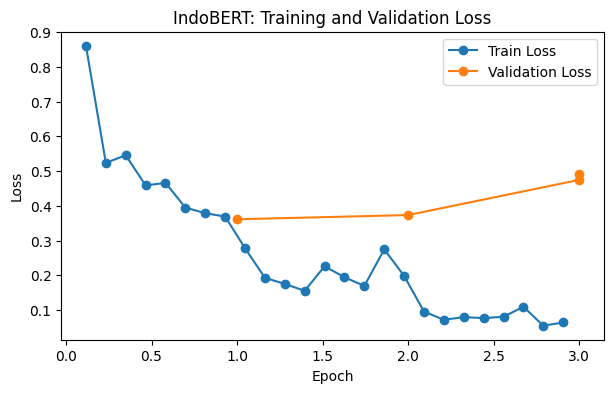

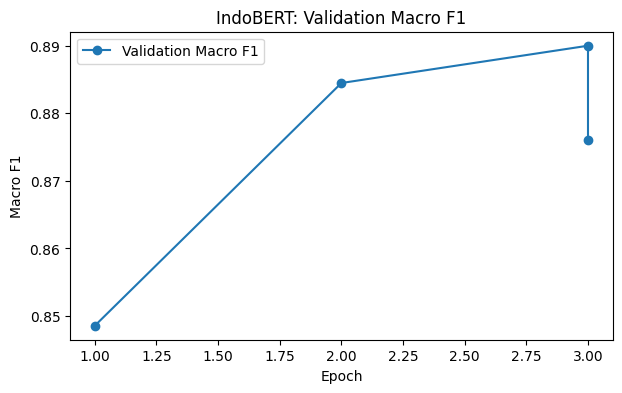

In [34]:
log_history = trainer.state.log_history

train_logs = []
eval_logs = []

for log in log_history:
    if "loss" in log and "epoch" in log:
        train_logs.append(log)
    if "eval_loss" in log and "epoch" in log:
        eval_logs.append(log)

train_log_df = pd.DataFrame(train_logs)
eval_log_df = pd.DataFrame(eval_logs)

plt.figure(figsize=(7, 4))

if not train_log_df.empty:
    plt.plot(train_log_df["epoch"], train_log_df["loss"], marker="o", label="Train Loss")

if not eval_log_df.empty:
    plt.plot(eval_log_df["epoch"], eval_log_df["eval_loss"], marker="o", label="Validation Loss")

plt.title("IndoBERT: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

if not eval_log_df.empty and "eval_macro_f1" in eval_log_df.columns:
    plt.figure(figsize=(7, 4))
    plt.plot(eval_log_df["epoch"], eval_log_df["eval_macro_f1"], marker="o", label="Validation Macro F1")
    plt.title("IndoBERT: Validation Macro F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.legend()
    plt.show()

=== LLM-based Model: Fine-tuned IndoBERT ===
              precision    recall  f1-score   support

    negative       0.87      0.88      0.87       387
     neutral       0.89      0.87      0.88       653
    positive       0.87      0.88      0.88       433

    accuracy                           0.88      1473
   macro avg       0.87      0.88      0.88      1473
weighted avg       0.88      0.88      0.88      1473



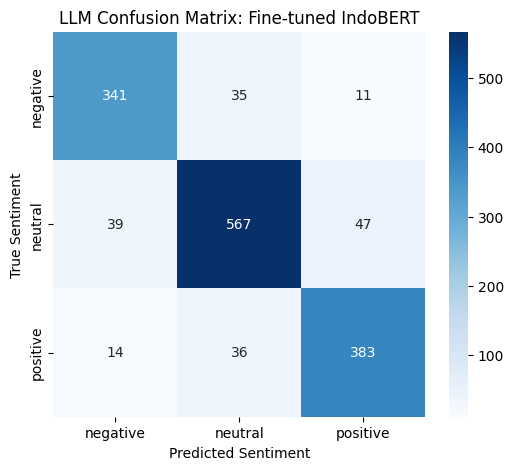

In [33]:
bert_predictions = trainer.predict(tokenized_dataset["test"])

bert_logits = bert_predictions.predictions
pred_bert = np.argmax(bert_logits, axis=1)

print("=== LLM-based Model: Fine-tuned IndoBERT ===")
print(classification_report(y_test, pred_bert, target_names=label_order, zero_division=0))

bert_results = compute_sklearn_metrics(
    y_test,
    pred_bert,
    "Fine-tuned IndoBERT"
)

plot_confusion_matrix(
    y_test,
    pred_bert,
    "LLM Confusion Matrix: Fine-tuned IndoBERT"
)

## Model Comparison

In [37]:
results_df = pd.DataFrame([
    baseline_results,
    bilstm_results,
    bert_results
])

display(results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted Precision,Weighted Recall,Weighted F1
0,TF-IDF + Logistic Regression,0.806517,0.802045,0.804312,0.803028,0.807191,0.806517,0.806705
1,Embedding + BiLSTM,0.797013,0.788013,0.790513,0.788738,0.798332,0.797013,0.797236
2,Fine-tuned IndoBERT,0.876443,0.874226,0.877988,0.876019,0.876663,0.876443,0.876460


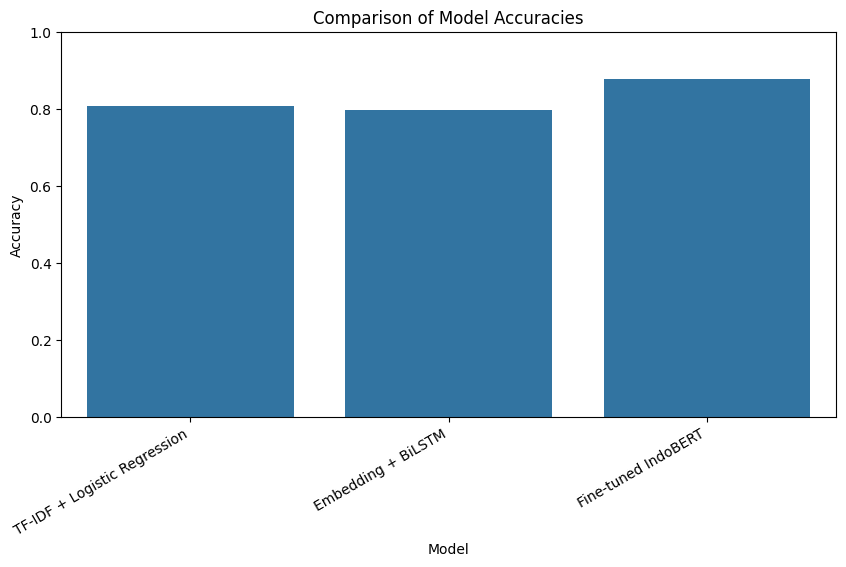

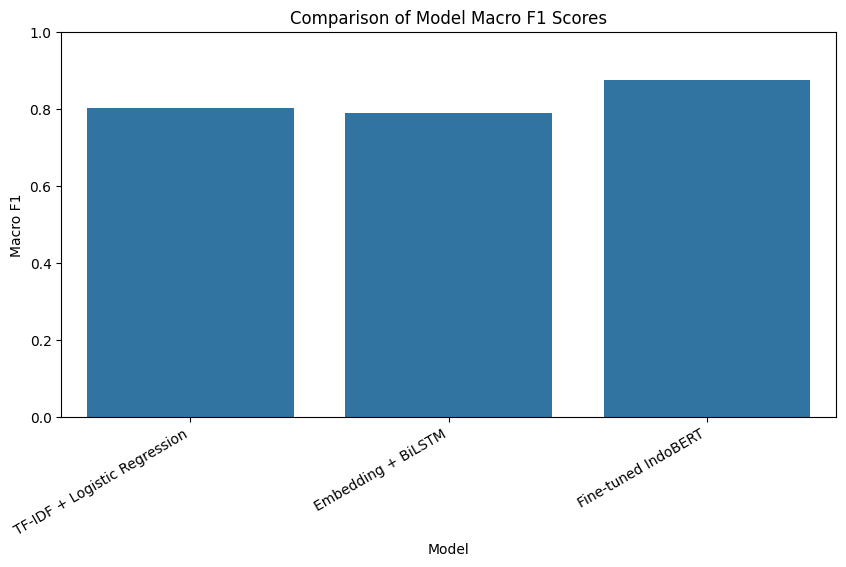

In [38]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Comparison of Model Accuracies")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Macro F1")
plt.title("Comparison of Model Macro F1 Scores")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.show()

### The results show that the fine-tuned IndoBERT model performed the best across all evaluation metrics. IndoBERT achieved 87.6% accuracy and 0.876 macro F1, clearly outperforming both TF-IDF + Logistic Regression and Embedding + BiLSTM, which achieved around 80% performance. This suggests that Transformer-based language models are better at understanding Indonesian financial news because they can capture context and semantic meaning more effectively than traditional bag-of-words or sequence models, even in the presence of dataset imbalances like in this scenario.

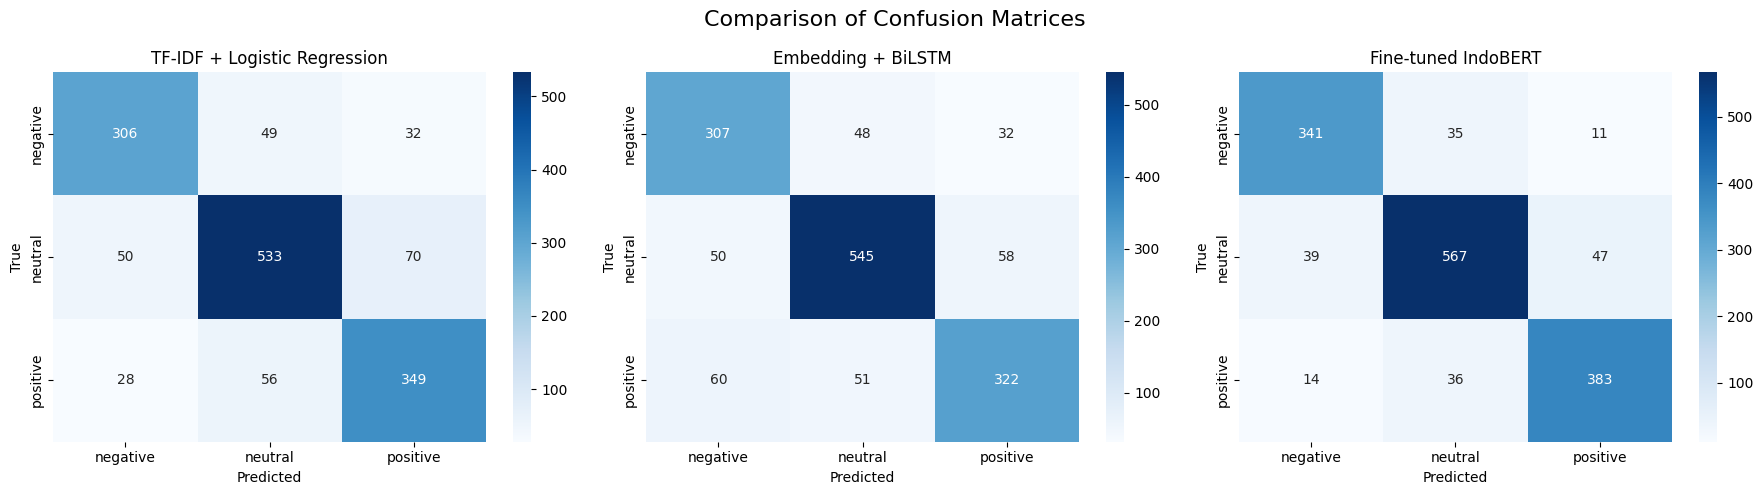

In [42]:
cm_baseline = confusion_matrix(y_test, pred_baseline)
cm_bilstm = confusion_matrix(y_test, pred_bilstm)
cm_bert = confusion_matrix(y_test, pred_bert)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("TF-IDF + Logistic Regression", cm_baseline),
    ("Embedding + BiLSTM", cm_bilstm),
    ("Fine-tuned IndoBERT", cm_bert)
]

for ax, (title, cm) in zip(axes, models):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_order,
        yticklabels=label_order,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Comparison of Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.show()

### The confusion matrices show that fine-tuned IndoBERT makes the most correct predictions across all three classes. It improves negative classification from 306/307 correct to 341 correct, neutral from 533/545 to 567 correct, and positive from 349/322 to 383 correct.

### IndoBERT also reduces the most serious errors. For example, positive headlines wrongly predicted as negative drop from 28 in TF-IDF and 60 in BiLSTM to only 14 in IndoBERT. Overall, the Transformer model is better at separating positive, neutral, and negative sentiment, while TF-IDF and BiLSTM make more confusion between neutral and the two sentiment classes.

## Qualitative Error Analysis of IndoBERT

In [41]:
error_df = test_df.copy()
error_df["pred_label"] = pred_bert
error_df["pred_sentiment"] = error_df["pred_label"].map(id2label)
error_df["true_sentiment"] = error_df["label"].map(id2label)
error_df["correct"] = error_df["pred_label"] == error_df["label"]

print("Correct examples:")
display(
    error_df[error_df["correct"] == True][
        ["text_raw", "true_sentiment", "pred_sentiment"]
    ].head(20)
)

print("Misclassified examples:")
display(
    error_df[error_df["correct"] == False][
        ["text_raw", "true_sentiment", "pred_sentiment"]
    ].head(20)
)

Correct examples:


,text_raw,true_sentiment,pred_sentiment
8892,"Resmi Ditunda, Kapan Shortselling Dibuka Kembali?",neutral,neutral
8713,Peserta Asuransi Wajib Tahu! Sepele tapi Bisa ...,neutral,neutral
7780,Airlangga Ungkap 71 Ribu UMKM Dapat 'Pengampun...,positive,positive
7131,"Banyak Menanti Data AS Hari Ini, Waspada Rupia...",negative,negative
4567,"Konflik Timur Tengah Masih Panas, Dolar Turun ...",positive,positive
1067,"IHSG Anjlok 2% Lebih, Bos Bursa Ungkap Penyeba...",negative,negative
6896,"Ketentuan Terbaru Saldo Minimum BCA, BRI, BNI,...",neutral,neutral
8941,"BUMN Karya Ini Punya Utang Rp 45,8 Triliun, Si...",neutral,neutral
8652,Ternyata Ini Alasan Tony Blair Masuk Dewan Pen...,neutral,neutral
4355,"OJK Tuntaskan 131 Perkara Keuangan, Sektor Ini...",neutral,neutral


Misclassified examples:


,text_raw,true_sentiment,pred_sentiment
1480,"Heboh Tapera, Ini Daftar 4 Mega Korupsi Dana K...",neutral,negative
1017,Bos Garuda: Citilink Gabung Pelita Air Barenga...,neutral,positive
3972,"Suku Bunga Fed Akhirnya Dipangkas, Sri Mulyani...",positive,neutral
1395,KPK Panggil Bos Insight Investment di Kasus Ta...,neutral,negative
3199,OJK Dorong Jiwasraya Selesaikan Penyelamatan P...,neutral,positive
806,"BCA Siapkan Duit Rp 68,80 T Buat Ramadan dan L...",neutral,positive
3967,Wow! 20% Penerimaan Negara Disumbang BUMN,positive,neutral
5442,"Pelaku Pasar Mulai Profit Taking, Wall Street ...",negative,neutral
5316,"NPL Turun, Bos BRI Ungkap Kunci Mengelola Kual...",positive,negative
6282,"Garuda Group Layani 146 Rute, Ini Wilayah Terp...",neutral,positive


### IndoBERT made mistakes mainly because many financial headlines are ambiguous without reading the full article. Neutral news containing words like korupsi, utang, or KPK were often predicted as negative because those words sound emotionally negative. On the other hand, some neutral company news was predicted as positive because the headlines sounded beneficial for business or investors.

### The model also struggled with positive sentiment that was implied indirectly. Headlines about Fed rate cuts, BUMN contributions, or BRImo services may look neutral on the surface but are considered positive in financial markets. Overall, IndoBERT understands Indonesian language well, but financial sentiment is harder because many headlines require market context and interpretation.